# 06 — 記憶與 Checkpointer：讓 graph 記得「之前發生過的事」

**這份要學什麼**
- Checkpointer + `thread_id`：同一個對話串內的短期記憶怎麼運作
- `get_state_history` / `update_state` / Time Travel（從舊存檔分岔出新的一條路）
- 對話變長怎麼辦：`trim_messages` 硬砍 vs `SummarizationMiddleware` 用 AI 寫摘要

> 不需要 API key。這章講的是 LangGraph 怎麼「存檔」，跟用哪個 LLM 無關。

到目前為止，每次 `graph.invoke(...)` 都是各自獨立的一次執行——執行完就忘光，下一次呼叫等於重新開機。這一份要解決的問題是：**怎麼讓圖記得上一次對話說過什麼**。

用玩遊戲比喻：

- **Checkpointer**：遊戲的「自動存檔系統」。每走一步（每個 node 執行完）就偷偷幫你存一次檔，完全不用自己按存檔鍵。這裡用的 `InMemorySaver` 是最簡單的一種，把存檔資料放在程式的記憶體裡。
- **`thread_id`**：你的「存檔檔案」。同一個 `thread_id` 就是接著同一個存檔繼續玩；換一個 `thread_id` 就是開新的一局，兩邊互不干擾。

具體做法只差一行：`builder.compile(checkpointer=InMemorySaver())`。之後呼叫時帶上同一個 `thread_id`，狀態就會自動接續，不用自己手動把歷史訊息組進輸入。

先看一眼等等會發生的事（對照下面 code cell 的真實輸出）：

```
thread_id="session-1"          ← 一個存檔檔案
  invoke("第一句話")
    存檔內容: [第一句話, 目前對話共 2 則]
  invoke("第二句話")            ← 沒有重傳第一句話，是自動接上去的
    存檔內容: [第一句話, 目前對話共 2 則, 第二句話, 目前對話共 4 則]

thread_id="session-2"          ← 換一個存檔檔案 = 全新一局
  invoke("這是另一個對話")
    存檔內容: [這是另一個對話, 目前對話共 2 則]   ← 跟 session-1 完全無關
```

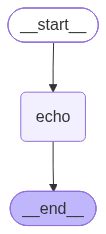

In [1]:
import sys

sys.path.insert(0, ".")
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

from _graph_viz import show_graph


def echo(state: MessagesState) -> dict:
    return {"messages": [("ai", f"目前對話共 {len(state['messages']) + 1} 則")]}


builder = StateGraph(MessagesState)
builder.add_node("echo", echo)
builder.add_edge(START, "echo")
builder.add_edge("echo", END)

graph = builder.compile(checkpointer=InMemorySaver())
show_graph(graph)

## `thread_id`：呼叫時用它指定「要接續哪個存檔」

透過 `config={"configurable": {"thread_id": ...}}` 告訴 LangGraph 要接的是哪一局。用同一個
`thread_id` 呼叫兩次，第二次的輸入會自動接在第一次的狀態後面——這是因為 `messages` 欄位標了
`add_messages` reducer（見 `03_langgraph_core.ipynb`），新訊息是「累加」而不是「覆蓋」。

In [2]:
config = {"configurable": {"thread_id": "session-1"}}

result_1 = graph.invoke({"messages": [("human", "第一句話")]}, config)
print(result_1["messages"][-1].content)

result_2 = graph.invoke({"messages": [("human", "第二句話")]}, config)
print([m.content for m in result_2["messages"]])  # 累積了四則：兩次 human + 兩次 ai

目前對話共 2 則
['第一句話', '目前對話共 2 則', '第二句話', '目前對話共 4 則']


## 換一個 `thread_id`，就是開新的一局

Checkpointer 是照 `thread_id` 分開存檔的。換一個 id，等於拿了另一個存檔檔案，完全看不到別的
session 存了什麼。

In [3]:
other_config = {"configurable": {"thread_id": "session-2"}}
other_result = graph.invoke({"messages": [("human", "這是另一個對話")]}, other_config)
print([m.content for m in other_result["messages"]])  # 只有兩則，跟 session-1 無關

['這是另一個對話', '目前對話共 2 則']


## `get_state` / `get_state_history`：看目前狀態，或倒轉回去看每一步

`get_state` 是「讀目前這個存檔檔案的最新進度」；`get_state_history` 是「把這個存檔檔案每一步的
快照都列出來」，由新到舊排序（倒序）。

`metadata["step"]` 是這個 `thread_id` 從頭到尾累加的步數——不是每次呼叫都重新從 0 算，而是同一個
存檔一路往上跳。`-1` 是「這個 thread 還沒套用任何輸入前」的起點，之後每呼叫一次圖，這個數字就繼續往上加。

In [4]:
print("目前狀態:", [m.content for m in graph.get_state(config).values["messages"]])
print()
print("歷史快照（倒序）:")
for snapshot in graph.get_state_history(config):
    print(" step", snapshot.metadata.get("step"), "->", [m.content for m in snapshot.values["messages"]])

目前狀態: ['第一句話', '目前對話共 2 則', '第二句話', '目前對話共 4 則']

歷史快照（倒序）:
 step 4 -> ['第一句話', '目前對話共 2 則', '第二句話', '目前對話共 4 則']
 step 3 -> ['第一句話', '目前對話共 2 則', '第二句話']
 step 2 -> ['第一句話', '目前對話共 2 則']
 step 1 -> ['第一句話', '目前對話共 2 則']
 step 0 -> ['第一句話']
 step -1 -> []


## `update_state`：不執行圖，直接改存檔內容

有時候需要「人工修正」對話歷史（例如審核後修改某一則訊息），不需要重新跑一次圖，直接呼叫
`update_state` 改存檔內容即可——這在 `07_langgraph_human_in_the_loop.ipynb` 的審核流程裡也會
用到類似的機制。

In [5]:
graph.update_state(config, {"messages": [("human", "這則是用 update_state 手動插入的")]})
print([m.content for m in graph.get_state(config).values["messages"]])

['第一句話', '目前對話共 2 則', '第二句話', '目前對話共 4 則', '這則是用 update_state 手動插入的']


## 讀取舊存檔、開新分支：Time Travel

`get_state_history` 只是「看」過去每一步的存檔。如果想「回到」某一步、從那裡重新玩
下去呢？把某個舊存檔的 `config`（裡面帶著那一步的 `checkpoint_id`）拿去 `invoke`，
就會從那個時間點分岔出一條新的路——這個 `thread_id` 的「最新進度」也會跳到這條新路上。
舊的那條路（原本再往後的存檔）不會被刪除，只是不再是「最新」而已，就像玩遊戲讀取一個
舊存檔重玩，原本存檔繼續往下的紀錄還在，只是你現在走的是新的一條路。

In [6]:
history = list(graph.get_state_history(config))
fork_point = next(h for h in history if h.metadata.get("step") == 0)  # 回到只有「第一句話」的那一步
print("要從這裡分岔:", [m.content for m in fork_point.values["messages"]])

forked_result = graph.invoke({"messages": [("human", "改走另一條路的第二句")]}, fork_point.config)
print("分岔後的新路:", [m.content for m in forked_result["messages"]])

要從這裡分岔: ['第一句話']
分岔後的新路: ['第一句話', '改走另一條路的第二句', '目前對話共 3 則']


## 存檔會一直長大：`trim_messages`

checkpointer 的 `messages` 是「只加不減」的（`add_messages` reducer），對話越聊越長，
每次呼叫都要把整份歷史送給模型——就像手機相簿一直拍照不刪，總有一天會爆容量、
傳一張照片也變慢。`trim_messages` 是最直接的做法：訂一個上限，超過就把最舊的訊息砍掉，
只留最近的。

In [7]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, trim_messages


def rough_length(msgs: list) -> int:
    return sum(len(m.content) for m in msgs)  # 用字數簡單模擬 token 數


long_history = [
    SystemMessage("你是客服助理"),
    HumanMessage("我想問退貨流程，退貨流程到底是什麼，可以講詳細一點嗎" * 3),
    AIMessage("退貨流程說明：請在七天內申請，並附上發票" * 3),
    HumanMessage("我要查訂單"),
    AIMessage("訂單編號是多少？"),
    HumanMessage("12345，這是最新的問題"),
]

trimmed = trim_messages(
    long_history,
    max_tokens=40,
    token_counter=rough_length,
    strategy="last",  # 保留「最新」的訊息，砍掉舊的
    include_system=True,  # SystemMessage 通常要保留，不能被砍掉
)
print(f"原本 {len(long_history)} 則，裁剪後剩 {len(trimmed)} 則：")
for m in trimmed:
    print(f"  {type(m).__name__:14} {m.content[:20]!r}")

原本 6 則，裁剪後剩 4 則：
  SystemMessage  '你是客服助理'
  HumanMessage   '我要查訂單'
  AIMessage      '訂單編號是多少？'
  HumanMessage   '12345，這是最新的問題'


## 用 AI 幫你寫摘要，取代硬刪：`SummarizationMiddleware`

`trim_messages` 是直接砍，砍掉的內容就真的不見了。如果舊對話裡有重要資訊（例如使用者
說過的偏好），直接砍可能會漏掉。`langchain.agents.middleware` 提供的
`SummarizationMiddleware` 換一種做法：對話長到一定程度，先叫 LLM 把舊的部分寫成一段
摘要，用這段摘要取代原本那一大串訊息，而不是整批丟掉。

**版本提醒**：舊版 LangGraph 是用 `pre_model_hook` 手動接摘要邏輯；`langchain 1.x`
把這個包成 `create_agent` 可以直接掛的 `middleware`，不用自己手刻 hook 了。

In [8]:
import sys

sys.path.insert(0, ".")
from _llm import scripted_model

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware

summarizer_model = scripted_model(
    ["SESSION摘要：使用者問過退貨流程與訂單查詢，尚未提供訂單編號以外的細節。"]
)
reply_model = scripted_model(["好的，我根據前面的摘要繼續協助你。"])

summarizing_agent = create_agent(
    model=reply_model,
    tools=[],
    middleware=[SummarizationMiddleware(model=summarizer_model, trigger=("messages", 4), keep=("messages", 2))],
)

result = summarizing_agent.invoke({"messages": long_history})
for m in result["messages"]:
    print(f"{type(m).__name__:14} {m.content[:40]!r}")

HumanMessage   'Here is a summary of the conversation to'
AIMessage      '訂單編號是多少？'
HumanMessage   '12345，這是最新的問題'
AIMessage      '好的，我根據前面的摘要繼續協助你。'


## 小結
- Checkpointer 讓「多輪對話」變成「同一個 `thread_id` 反覆呼叫」，狀態自動接續，不用自己手動
  組裝歷史訊息——就像同一個存檔檔案玩到哪存到哪
- `InMemorySaver` 只存在行程記憶體裡，程式一關就消失——正式環境要換成
  `SqliteSaver` / `PostgresSaver`（`10_langgraph_persistence_deploy.ipynb` 會示範）
- `get_state_history` 讓你可以倒轉回去看「圖到底一步一步做了什麼」，`update_state` 讓你可以
  在不重跑的情況下修正存檔內容

下一份：`07_langgraph_human_in_the_loop.ipynb`，用 `interrupt()` 讓圖在某個節點暫停，
等人工核准後再繼續——這一招也是靠這章的 Checkpointer 才能運作。